In [5]:
'''data extraction'''

import pandas as pd
import numpy as np

f = open('kazuki_data.json')
kazuki_data = pd.read_json(f, orient='split')
f.close()
f = open('watara_data.json')
watara_data = pd.read_json(f, orient='split')
f.close()
f = open('yokoi_data.json')
yokoi_data = pd.read_json(f, orient='split')
f.close()

training = pd.concat([kazuki_data, yokoi_data.loc[0,:].iloc[:2000], yokoi_data.loc[1,:].iloc[:200]])
validation = pd.concat([watara_data, yokoi_data.loc[0,:].iloc[2000:], yokoi_data.loc[1,:].iloc[200:]])

t_healthy = training.loc[0]
t_cancer = training.loc[1]
v_healthy = validation.loc[0]
v_cancer = validation.loc[1]

m_t_healthy = t_healthy.shape[0]
m_t_cancer = t_cancer.shape[0]
m_v_healthy = v_healthy.shape[0]
m_v_cancer = v_cancer.shape[0]

n_mirnas = t_healthy.shape[1] #gets number of columns
miRNA_names_list = list(t_healthy.columns)

print("healthy training data")
print(t_healthy.shape)
print(t_healthy.head)
print("cancer training data")
print(t_cancer.shape)
print(t_cancer.head)
print("healthy validation data")
print(v_healthy.shape)
print(v_healthy.head)
print("cancer validation data")
print(v_cancer.shape)
print(v_cancer.head)

healthy training data
(6965, 2565)
<bound method NDFrame.head of     MIMAT0000062  MIMAT0000063  MIMAT0000064  MIMAT0000065  MIMAT0000066  \
0          3.700         3.669        -2.681         3.499        -2.681   
0         -4.018        -4.018        -4.018        -4.018        -4.018   
0          1.514         0.869         0.464        -0.987        -4.325   
0         -4.417        -4.417        -4.417        -1.036        -1.897   
0         -5.541         0.598        -5.281        -3.185         0.986   
..           ...           ...           ...           ...           ...   
0         -3.515         1.626         6.450        -3.515         1.136   
0         -3.160        -3.160        -3.160        -3.160        -3.160   
0         -3.717         0.509        -3.717        -3.717         1.166   
0         -2.374        -2.374         1.426         2.128         3.553   
0         -5.741         1.007        -5.741        -5.741        -5.741   

    MIMAT0000067  MIMA

In [6]:
'''Y = training cancer dataset. 
healthy comp is nxn matrix of 
comparison of expression of Ea>Eb'''
Y = t_healthy.values
healthy_comp = np.zeros((n_mirnas, n_mirnas))
for a in range(n_mirnas):
    for b in range(n_mirnas):
        healthy_comp[a,b]=np.sum(Y[:,a] > Y[:,b])
healthy_comp = healthy_comp / m_t_healthy
print(healthy_comp)

'''Z = training cancer dataset. 
cancer comp is nxn matrix of 
comparison of expression of Ea>Eb'''
Z = t_cancer.values
cancer_comp = np.zeros((n_mirnas, n_mirnas))
for a in range(n_mirnas):
    for b in range(n_mirnas):
        cancer_comp[a,b]=np.sum(Z[:,a] > Z[:,b])
cancer_comp = cancer_comp / m_t_cancer
print(cancer_comp)

[[0.         0.22368988 0.33725772 ... 0.13639627 0.41005025 0.42857143]
 [0.54515434 0.         0.57501795 ... 0.18880115 0.63460158 0.66245513]
 [0.29605169 0.20904523 0.         ... 0.11500359 0.4011486  0.42038765]
 ...
 [0.82311558 0.77774587 0.83833453 ... 0.         0.89375449 0.90193826]
 [0.19109835 0.14630294 0.20215363 ... 0.04005743 0.         0.25886576]
 [0.10150754 0.06661881 0.10911701 ... 0.03603733 0.15046662 0.        ]]
[[0.    0.45  0.525 ... 0.505 0.67  0.635]
 [0.4   0.    0.505 ... 0.475 0.645 0.665]
 [0.29  0.31  0.    ... 0.38  0.52  0.49 ]
 ...
 [0.4   0.43  0.455 ... 0.    0.59  0.56 ]
 [0.15  0.13  0.18  ... 0.145 0.    0.205]
 [0.14  0.125 0.215 ... 0.23  0.385 0.   ]]


In [7]:
'''decide on stable pairs from healthy'''
CONST_k = 0.95
stable_pairs = np.where((healthy_comp >= CONST_k) | (healthy_comp <= 1-CONST_k), 
                        1, 0)
'''you can figure this out. '''
CONST_l = 0.75
stable_cancer_pairs = np.where((cancer_comp >= CONST_l) | (cancer_comp <= 1-CONST_l), 
                        1, 0)
identity_matrix = np.identity(n_mirnas,dtype=bool)
candidate_diagnostic_pairs = (((stable_pairs) & (stable_cancer_pairs)) & 
                            ((np.absolute(healthy_comp - cancer_comp)) > 0.5) &
                            (~identity_matrix))

In [9]:
print(stable_pairs.nonzero()[0].shape)
print(candidate_diagnostic_pairs.nonzero()[0].shape)

(2563428,)
(235,)


In [12]:
'''there is a quite a bit of redundancy, but it's honeslty good'''
selected = candidate_diagnostic_pairs.nonzero()
print(selected[0].shape)
counts = np.bincount(selected[0])
for i, count in enumerate(counts):
    if count > 0:
        print(f"{i} occurs {count} times")


(235,)
81 occurs 4 times
135 occurs 10 times
148 occurs 3 times
167 occurs 3 times
334 occurs 1 times
345 occurs 3 times
430 occurs 1 times
489 occurs 1 times
535 occurs 1 times
542 occurs 2 times
573 occurs 1 times
589 occurs 1 times
614 occurs 1 times
668 occurs 1 times
673 occurs 4 times
688 occurs 3 times
697 occurs 1 times
713 occurs 12 times
714 occurs 4 times
730 occurs 1 times
731 occurs 1 times
732 occurs 1 times
745 occurs 6 times
765 occurs 1 times
791 occurs 1 times
836 occurs 1 times
873 occurs 1 times
931 occurs 1 times
957 occurs 2 times
965 occurs 2 times
966 occurs 2 times
970 occurs 1 times
979 occurs 1 times
980 occurs 1 times
1028 occurs 5 times
1050 occurs 1 times
1100 occurs 1 times
1123 occurs 1 times
1202 occurs 1 times
1206 occurs 1 times
1246 occurs 1 times
1298 occurs 1 times
1303 occurs 1 times
1319 occurs 1 times
1326 occurs 1 times
1430 occurs 1 times
1463 occurs 1 times
1477 occurs 1 times
1496 occurs 3 times
1499 occurs 3 times
1508 occurs 1 times
1571 o

In [134]:
'''generate training input'''
pair_dict_training = {}
for i in range(len(selected[0])):
    _key = f"{selected[0][i]},{selected[1][i]}"
    _healthy_sect = Y[:,selected[0][i]]> Y[:,selected[1][i]]
    _cancer_sect = Z[:,selected[0][i]]> Z[:,selected[1][i]]
    pair_dict_training[_key] = np.concat((_healthy_sect, _cancer_sect))
_index = np.concat((np.zeros(m_t_healthy),np.ones(m_t_cancer)))
X_unshuffled = pd.DataFrame(pair_dict_training, index = _index)
X = X_unshuffled.sample(frac=1, random_state=67)
y = pd.Series(list(X.index))
X = X.reset_index().drop('index', axis=1)

In [135]:
'''generate validation input'''
pair_dict_validation = {}
for i in range(len(selected[0])):
    _key = f"{selected[0][i]},{selected[1][i]}"
    _healthy_sect = A[:,selected[0][i]]> A[:,selected[1][i]]
    _cancer_sect = B[:,selected[0][i]]> B[:,selected[1][i]]
    pair_dict_validation[_key] = np.concat((_healthy_sect, _cancer_sect))
_index = np.concat((np.zeros(m_v_healthy),np.ones(m_v_cancer)))
Xv_unshuffled = pd.DataFrame(pair_dict_validation, index = _index)
Xv = Xv_unshuffled.sample(frac=1, random_state=67)
yv = pd.Series(list(Xv.index))
Xv = Xv.reset_index().drop('index', axis=1)

In [136]:
X.shape, Xv.shape, y.shape, yv.shape

((7165, 235), (1048, 235), (7165,), (1048,))

In [139]:
Xv

,"81,334","81,542","81,1053","81,2355","135,688","135,730","135,1600","135,1874","135,2167","135,2289",...,"2492,2174","2521,1773","2523,135","2523,1499","2525,673","2525,1748","2525,2419","2525,2443","2543,1587","2544,345"
0,False,False,True,False,True,False,True,True,True,False,...,True,True,False,False,True,True,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1043,True,True,False,False,True,True,True,False,True,True,...,False,True,False,False,True,False,True,True,False,True
1044,False,True,True,True,True,True,True,False,False,True,...,False,False,False,False,True,True,True,True,True,True
1045,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,False,False,False,False,False
1046,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,False,False,False,False,False,False


In [85]:
#logistic regression with lasso
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.feature_selection import RFE, RFECV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.pipeline import Pipeline

import scipy.stats
import math

# not importing scaling bc all of it is binary

OV_PREV = 0.0004

In [ ]:
svc = SVC(C=0.01,kernel='linear',class_weight=None)

rfe = RFE(estimator=svc, n_features_to_select=4, step=1)
#model = RFECV(estimator=svc, min_features_to_select = 1, step=1)
#rfe.fit(X,y)
X_selected_features = rfe.fit_transform(X,y)

In [ ]:
model = SVC(C=0.01, kernel='linear', class_weight=None)
model.fit(X_selected_features)

In [ ]:
y_pred = model.predict(X_selected_features)
y_prediction_values = np.array(y_pred)
cm = confusion_matrix(y, y_prediction_xvalues>0)
sensitivity = cm[1,1]/(cm[1,1]+cm[1,0])
specificity = (cm[0,0]/(cm[0,0]+cm[0,1]))
print("Confusion Matrix: \n", cm)
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

print(classification_report(y,y_prediction_values>0))

array([[False, False, False, False],
       [False, False, False, False],
       [False, False, False, False],
       ...,
       [False, False, False, False],
       [False, False, False, False],
       [False, False, False, False]], shape=(7165, 4))

,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1.0
spec,,,,,,,,,,,
0.50,0.000,0.025,0.050,0.075,0.100,0.125,0.150,0.175,0.200,0.225,0.250
0.55,0.075,0.100,0.125,0.150,0.175,0.200,0.225,0.250,0.275,0.300,0.325
0.60,0.150,0.175,0.200,0.225,0.250,0.275,0.300,0.325,0.350,0.375,0.400
0.65,0.225,0.250,0.275,0.300,0.325,0.350,0.375,0.400,0.425,0.450,0.475
0.70,0.300,0.325,0.350,0.375,0.400,0.425,0.450,0.475,0.500,0.525,0.550
0.75,0.375,0.400,0.425,0.450,0.475,0.500,0.525,0.550,0.575,0.600,0.625
0.80,0.450,0.475,0.500,0.525,0.550,0.575,0.600,0.625,0.650,0.675,0.700
0.85,0.525,0.550,0.575,0.600,0.625,0.650,0.675,0.700,0.725,0.750,0.775
0.90,0.600,0.625,0.650,0.675,0.700,0.725,0.750,0.775,0.800,0.825,0.850


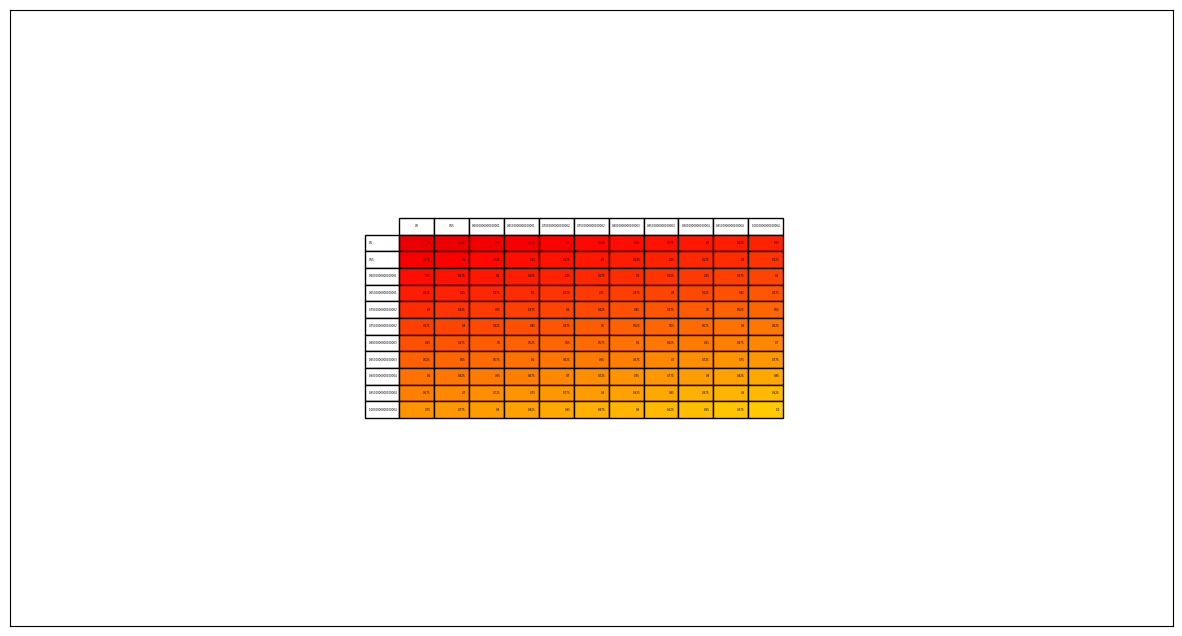

In [177]:
from sklearn.metrics import confusion_matrix, make_scorer

'''tuning the error metric im gonna use'''
'''sens/spec -> error metric'''
'''heavily penalize any spec < 99%'''
'''but still have sens be strong'''
def error_metric(sensitivity, specificity):
    fpr = 1-specificity
    fnr = 1-sensitivity 
    return 1-(fpr*3 + fnr)/2
def custom_error_metric(y_true, y_pred):
    tn,fp,fn,tp = confusion_matrix(y_true,y_pred).ravel()
    sensitivity = tp / (tp+fn)
    specificity = tn / (tn+fp) 
    return error_metric(sensitivity,specificity)
CustomErrorMetric = make_scorer(custom_error_metric,
                                greater_is_better=True)

dict_error = {}
dict_error['spec'] = np.arange(0.5,1.01,0.05)
for sens in np.arange(0.5,1.01,0.05):
    dict_error[sens] = []
    for spec in np.arange(0.5,1.01,0.05):
        dict_error[sens].append(error_metric(sens,spec))
error_df = pd.DataFrame(dict_error)
error_df.set_index('spec',inplace=True)

idx = error_df.index
vals = np.around(error_df.values, 3)
norm = plt.Normalize(vals.min()-1, vals.max()+1)
colours = plt.cm.hot(norm(vals))
fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111, frameon=True, xticks=[], yticks=[])

the_table=plt.table(cellText=vals, rowLabels=error_df.index, colLabels=error_df.columns, 
                    colWidths = [0.03]*vals.shape[1], loc='center', 
                    cellColours=colours)
#plt.show()
error_df


# NESTED CROSS VALIDATION

In [189]:
from sklearn.base import BaseEstimator, ClassifierMixin

class CustomPredictSVC (BaseEstimator, ClassifierMixin):
    def __init__(self, C=1.0, class_weight=None, 
                 threshold=0,
                 random_state = 67):
        self.C = C
        self.class_weight = class_weight
        self.threshold = threshold
        self.random_state = random_state

        self.svc_estimator = SVC(
            C = self.C,
            class_weight=self.class_weight,
            random_state=self.random_state,
            kernel="linear"
        )

    def fit(self,X,y):
        self.svc_estimator.fit(X,y)
        self.classes_ = self.svc_estimator.classes_
        return self
    def predict(self, X):
        decisions = self.svc_estimator.decision_function(X)
        return decisions > self.threshold
    def score(self, X, y):
        y_pred = self.predict(X)
        _cm = confusion_matrix(y, y_pred)
        _sensitivity = _cm[1,1]/(_cm[1,1]+_cm[1,0])
        _specificity = (_cm[0,0]/(_cm[0,0]+_cm[0,1]))
        return error_metric(_sensitivity, _specificity)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

p_grid = {"rfe__n_features_to_select":[3,4,5],
          "svc__C": scipy.stats.uniform(5,15), 
          "svc__class_weight":['balanced', None],
#         "svc__threshold": scipy.stats.uniform(-1.5,2.5),
          }
pipeline = Pipeline(steps=[('scalar', StandardScaler(copy=True, with_mean=True, with_std=True)),
                           ('rfe', RFE(estimator=SVC(kernel="linear"))),
                           ('svc', CustomPredictSVC())])

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=67)
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=67)

best_params_per_fold = []

scores = []
#arrays to store scores
for train_ind, test_ind in outer_cv.split(X,y):
    '''train_ind and test_ind are a np array of indices
    3:1 split around 5370,1790'''
    _X_t, _X_v = X.iloc[train_ind], X.iloc[test_ind]
    _y_t, _y_v = y.iloc[train_ind], y.iloc[test_ind]

    param_search = RandomizedSearchCV(estimator=pipeline, 
                             param_distributions=p_grid, 
                             cv=inner_cv, 
                             random_state=67,
                             refit=True) 
    param_search.fit(_X_t, _y_t)

    best_params_per_fold.append(param_search.best_params_)

    inner_model = param_search.best_estimator_
    outer_score = inner_model.score(_X_v, _y_v)
    scores.append(outer_score)

print(f"scores of each test part of fold: {scores}")
print("list of best params in each outer fold")
print(best_params_per_fold)
    

KeyboardInterrupt: 

scores of each test part of fold: [np.float64(0.8682778415614236), np.float64(0.9156921309592188), np.float64(0.9565537047673751), np.float64(0.9674152785755313)]

list of best params in each outer fold
[{'rfe__n_features_to_select': 6, 'svc__C': np.float64(16.271360426268345), 'svc__class_weight': None}, 
{'rfe__n_features_to_select': 6, 'svc__C': np.float64(16.271360426268345), 'svc__class_weight': None}, 
{'rfe__n_features_to_select': 6, 'svc__C': np.float64(16.271360426268345), 'svc__class_weight': None}, 
{'rfe__n_features_to_select': 6, 'svc__C': np.float64(16.271360426268345), 'svc__class_weight': None}]

In [252]:
pipeline.set_params(**{"rfe__n_features_to_select":6,
          "svc__C": 0.01, 
          "svc__class_weight": "balanced",
          "svc__threshold": 0,
          })

pipeline.fit(X, y)

,steps,"[('scalar', ...), ('rfe', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,estimator,SVC(kernel='linear')
,n_features_to_select,6
,step,1
,verbose,0


In [253]:
y_pred = pipeline.predict(X)
cm = confusion_matrix(y, y_pred)
sensitivity = cm[1,1]/(cm[1,1]+cm[1,0])
specificity = (cm[0,0]/(cm[0,0]+cm[0,1]))
print("Confusion Matrix: \n", cm)
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

print(classification_report(y,y_prediction_values>0))

Confusion Matrix: 
 [[6948   17]
 [  13  187]]
Sensitivity (Recall): 0.9350
Specificity: 0.9976
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97      6965
         1.0       0.03      0.03      0.03       200

    accuracy                           0.95      7165
   macro avg       0.50      0.50      0.50      7165
weighted avg       0.95      0.95      0.95      7165



In [254]:
yv_pred = pipeline.predict(Xv)

cmv = confusion_matrix(yv, yv_pred)
sensitivity = cmv[1,1]/(cmv[1,1]+cmv[1,0])
specificity = (cmv[0,0]/(cmv[0,0]+cmv[0,1]))
print("Confusion Matrix: \n", cmv)
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

print(classification_report(y,y_pred>0))

Confusion Matrix: 
 [[867  21]
 [ 69  91]]
Sensitivity (Recall): 0.5687
Specificity: 0.9764
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6965
         1.0       0.92      0.94      0.93       200

    accuracy                           1.00      7165
   macro avg       0.96      0.97      0.96      7165
weighted avg       1.00      1.00      1.00      7165



# BAGGING CLASSIFIER DOWN BELOW

In [ ]:
bag_model = BaggingClassifier(estimator=model, n_estimators = 10, random_state=67)
bag_model.fit(X,y)

bag_model.estimators_[0].ranking_


array([359,  79, 268, 154, 220, 251, 118, 159, 177, 271, 201, 411,   1,
         3, 469, 343,  25, 282, 281,  26, 184, 351, 459, 420,  36,  97,
       463, 344, 246, 307, 133, 475, 386, 399, 354, 387, 264, 283, 192,
       403, 137, 162, 418, 439,  71, 291,  48, 232,  34,  65, 231,   5,
       286, 301, 252, 378,   6, 297, 323,   9,  63, 276,  47,  84, 350,
       345, 417,  30, 158,  49, 114, 476, 207,  82,  13, 452, 330, 228,
       328, 238,  66, 385, 108, 461, 257, 144, 265, 258, 267, 401,  16,
       260, 167, 136, 451, 186, 163, 214, 255,   1, 369, 432, 470, 465,
       464,  80,   1,  55,  46, 319, 208, 170, 109,  22, 150, 174, 298,
       412,   8, 410, 341, 315, 152, 364, 182, 400, 263, 235,  27, 172,
        53,  10, 185, 122, 324,  21,  89,  96, 219,  31, 142,  94, 128,
       380, 449, 444, 340, 126, 373,  35, 262, 454, 347, 237, 374, 110,
        69,  72, 338, 195, 306, 275, 352, 356, 248, 367, 157, 171,  17,
        77,  12,  85, 138, 280,  29, 389, 365,  58, 366, 203, 34

In [ ]:
pipeline.get_params

{'memory': None,
 'steps': [('rfe', RFE(estimator=SVC(kernel='linear'))),
  ('svc', CustomPredictSVC())],
 'transform_input': None,
 'verbose': False,
 'rfe': RFE(estimator=SVC(kernel='linear')),
 'svc': CustomPredictSVC(),
 'rfe__estimator__C': 1.0,
 'rfe__estimator__break_ties': False,
 'rfe__estimator__cache_size': 200,
 'rfe__estimator__class_weight': None,
 'rfe__estimator__coef0': 0.0,
 'rfe__estimator__decision_function_shape': 'ovr',
 'rfe__estimator__degree': 3,
 'rfe__estimator__gamma': 'scale',
 'rfe__estimator__kernel': 'linear',
 'rfe__estimator__max_iter': -1,
 'rfe__estimator__probability': False,
 'rfe__estimator__random_state': None,
 'rfe__estimator__shrinking': True,
 'rfe__estimator__tol': 0.001,
 'rfe__estimator__verbose': False,
 'rfe__estimator': SVC(kernel='linear'),
 'rfe__importance_getter': 'auto',
 'rfe__n_features_to_select': None,
 'rfe__step': 1,
 'rfe__verbose': 0,
 'svc__C': 1.0,
 'svc__class_weight': None,
 'svc__random_state': 67,
 'svc__threshold': 0

In [38]:
avg_ranking = np.concatenate(tuple([np.reshape(bag_model.estimators_[i].ranking_, (-1,1)) for i in range(10)]), axis=1)
avg_ranking

array([[359, 219, 368, ..., 227, 169, 369],
       [103, 395, 298, ..., 407, 263, 324],
       [268,  86, 292, ..., 321, 253, 316],
       ...,
       [462, 113,  98, ...,  25, 133, 454],
       [388, 433, 227, ..., 192, 242, 223],
       [421, 131, 153, ..., 149, 252, 465]], shape=(485, 10))

In [ ]:
avg_ranking = np.sum(avg_ranking, axis=1) / 10

array([329.4, 303.1, 230.8, 228.5, 183.3, 345.4, 370.1, 238.9, 302.8,
       152.6, 293.5, 332.2, 143.1, 160. , 312.3, 261.8, 214.8, 333.6,
       347.5, 169.3, 355.3, 271.9, 319. , 258.3,  49.6, 239.7, 372.9,
       258.1, 273.1, 265.8, 143.1, 326.2, 315.8, 306.8, 257.6, 212.4,
       205.4, 265.5, 315.1, 286.8, 318. , 327.5, 290.3, 290.8,  68.3,
       343.3, 139.6, 299.6,  18.2, 208.4, 236.3,  85.6, 366.3, 249.1,
       295.8, 285.8,  73.5, 343.9, 237.6,  76.9, 150.9, 287.2,  39.3,
       339.4, 208.2, 331.7, 290.9, 100.6, 164.6, 173.3, 166.3, 285.7,
       279.8, 204.9, 235.9, 243.4, 272.8, 101.1, 149.2, 265.9,  63.1,
       294.4, 236.9, 363.9, 342.2, 294.2, 278.9, 331.5, 156.5, 358.5,
        29.7, 206. , 335.4, 301.7, 357. , 149.2, 115.4, 203.3, 158.3,
        10.7, 235. , 263.1, 284. , 288.3, 340.9, 297.3, 105.7,  16.2,
        27.3, 262. , 246.6, 335.4, 300.8,  47.5, 193.5, 295.6, 329.3,
       271.5, 149. , 336.6, 300.2, 241.2, 283.9, 342.2, 319. , 195.9,
       317.2, 247.5,

In [43]:
y_pred = bag_model.decision_function(X)
y_prediction_values = np.array(y_pred)
cm = confusion_matrix(y, y_prediction_values>0)
sensitivity = cm[1,1]/(cm[1,1]+cm[0,1])
specificity = (cm[0,0]/(cm[0,0]+cm[1,0]))
print("Confusion Matrix: \n", cm)
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(classification_report(y,y_prediction_values>0))

Confusion Matrix: 
 [[6960    5]
 [  12  188]]
Sensitivity (Recall): 0.9741
Specificity: 0.9983
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6965
         1.0       0.97      0.94      0.96       200

    accuracy                           1.00      7165
   macro avg       0.99      0.97      0.98      7165
weighted avg       1.00      1.00      1.00      7165



In [ ]:
yv_pred = model.decision_function(Xv)
yv_prediction_values = np.array(yv_pred)
cmv = confusion_matrix(yv, yv_prediction_values>0)
sensitivityv = cmv[1,1]/(cmv[1,1]+cmv[0,1])
specificityv = (cmv[0,0]/(cmv[0,0]+cmv[1,0]))
print("Confusion Matrix: \n", cmv)
print(f"Sensitivity (Recall): {sensitivityv:.4f}")
print(f"Specificity: {specificityv:.4f}")
print(classification_report(yv,yv_prediction_values>0))

Confusion Matrix: 
 [[859  29]
 [  7 153]]
Sensitivity (Recall): 0.8407
Specificity: 0.9919
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98       888
         1.0       0.84      0.96      0.89       160

    accuracy                           0.97      1048
   macro avg       0.92      0.96      0.94      1048
weighted avg       0.97      0.97      0.97      1048

